# Частотный взгляд на нейросети: гармонический анализ, F -принцип и динамика обучения 
## Практическая часть
### Цели: 
- Проверить на синтетических примерах наличие F-принципа 
- Установить практически насколько сильно признаки Фурье ускоряют обучение высоких частот
- Исследовать влияние ширины сети и шага обучения на спектральные кривые 

### F-принцип на синтетических примерах

#### Установка необходимых библиотек:

In [9]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import random

def set_seed(seed=42):
    random.seed(seed)                # стандартный python
    np.random.seed(seed)             # numpy
    torch.manual_seed(seed)          # CPU
    torch.cuda.manual_seed(seed)     # GPU
    torch.cuda.manual_seed_all(seed) # все GPU

set_seed(42)

torch.use_deterministic_algorithms(True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#### Целевые функции

In [10]:
#сумма синусов с заданными частотами и амплитудами
def generate_1d_function(n_samples=1024, freqs=[1, 3, 5], amplitudes=None):
    x = np.linspace(0, 2*np.pi, n_samples)
    
    if amplitudes is None:
        amplitudes = np.ones(len(freqs))
    
    y = np.zeros_like(x)
    for a, f in zip(amplitudes, freqs):
        y += a * np.sin(f * x)
    
    return x, y

#### MLP сеть

In [11]:
class MLP(nn.Module):
    def __init__(self, in_dim=1, hidden=256, depth=6, activation='tanh'):
        super().__init__()
        
        act = nn.Tanh() if activation == 'tanh' else nn.ReLU()
        
        layers = [nn.Linear(in_dim, hidden), act]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), act]
        layers += [nn.Linear(hidden, 1)]
        
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

#### Фурье-коэффициенты

In [12]:
# 1D FFT
def compute_fft_1d(signal):
    fft = np.fft.fft(signal)
    return fft

#### Визуализация

##### Ошибки по частотам

In [13]:
def plot_spectral_dynamics(spectral_errors, true_freqs):
    spectral_errors = np.array(spectral_errors)

    # делим частоты на низкие и высокие
    sorted_freqs = sorted(true_freqs)
    mid = len(sorted_freqs) // 2
    
    low_freqs = sorted_freqs[:mid]
    high_freqs = sorted_freqs[mid:]
    
    plt.figure(figsize=(10, 6))
    
    for k in sorted_freqs:
        plt.plot(
            spectral_errors[:, k],
            linewidth=2.5,
            label=f"k={k} (true)"
        )
    
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("E_k(t)")
    plt.title("Spectral Error Dynamics (highlighted true frequencies)")
    
    plt.legend()
    plt.tight_layout()
    plt.show()

    # отдельно низкие частоты
    plt.figure(figsize=(10, 6))
    
    for k in low_freqs:
        plt.plot(
            spectral_errors[:, k],
            linewidth=2.5,
            label=f"k={k}"
        )
    
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("E_k(t)")
    plt.title("Low Frequencies")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # отдельно высокие частоты
    plt.figure(figsize=(10, 6))
    
    for k in high_freqs:
        plt.plot(
            spectral_errors[:, k],
            linewidth=2.5,
            label=f"k={k}"
        )
    
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("E_k(t)")
    plt.title("High Frequencies")
    plt.legend()
    plt.tight_layout()
    plt.show()

##### Итог обучения

In [14]:
def plot_fit(x, y, model):
    with torch.no_grad():
        pred = model(torch.tensor(x, dtype=torch.float32).unsqueeze(1).to(device))
        pred = pred.cpu().numpy()
    
    plt.plot(x, y, label="True")
    plt.plot(x, pred, '--', label="MLP")
    plt.legend()
    plt.show()

#### Обучение и измерение спектра

In [15]:
def train_with_spectral_tracking(x, y, epochs, lr=1e-2, activation='tanh'):
    
    x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(1).to(device)
    y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1).to(device)
    
    model = MLP(activation=activation).to(device)
    loss_fn = nn.MSELoss()
    
    # истинный спектр
    true_fft = compute_fft_1d(y)
    
    spectral_errors = []
    
    for epoch in range(epochs):
        
        # прямой проход 
        pred = model(x_tensor)
        loss = loss_fn(pred, y_tensor)
        
        # вычисление градиентов 
        loss.backward()
        
        # явный шаг градиентного спуска
        with torch.no_grad(): # отключаем автоматическое обновление параметров
            for param in model.parameters():
                param -= lr * param.grad
        
        # обнуление градиентовв, чтобы избежать накопления
        model.zero_grad()
        
        # спектральный анализ
        with torch.no_grad():
            pred_np = pred.cpu().numpy().flatten()
            pred_fft = compute_fft_1d(pred_np)
            
            Ek = np.abs(true_fft - pred_fft) ** 2
            spectral_errors.append(Ek)

        # каждые 10000 итераций визуализируем текущую аппроксимацию
        if epoch % 10000 == 0:
            plot_fit(x, y, model)
            print(f"Epoch {epoch}, Loss {loss.item():.6f}")
    
    return model, np.array(spectral_errors), true_fft

#### Запуск эксперимента

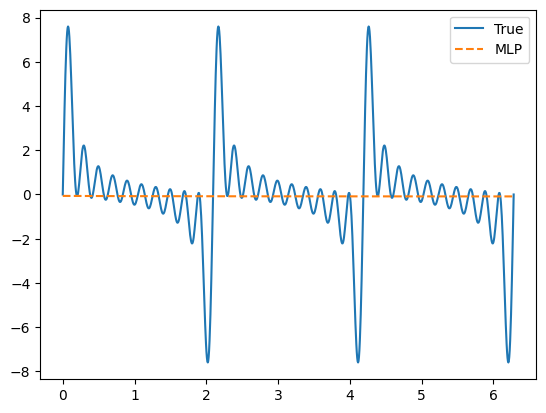

Epoch 0, Loss 5.013363


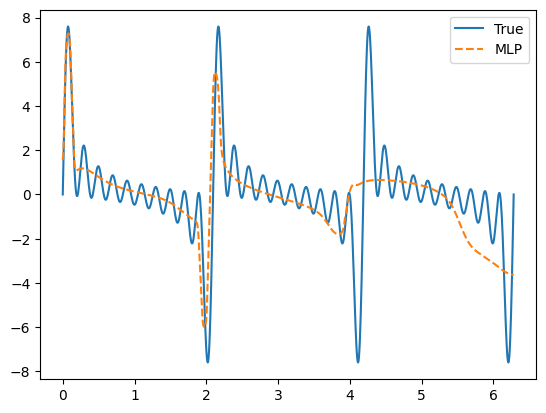

Epoch 10000, Loss 2.292984


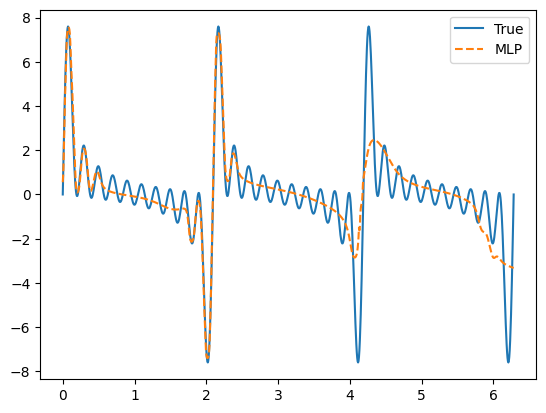

Epoch 20000, Loss 1.374890


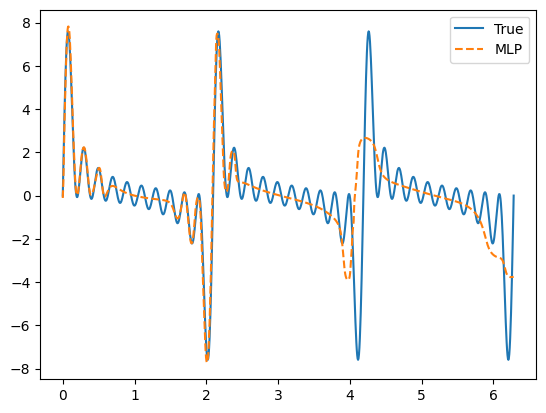

Epoch 30000, Loss 1.326895


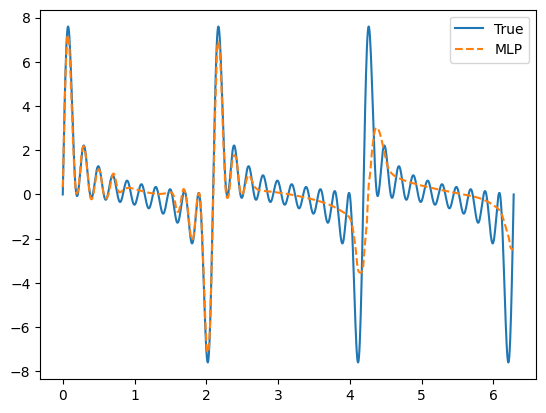

Epoch 40000, Loss 2.126223


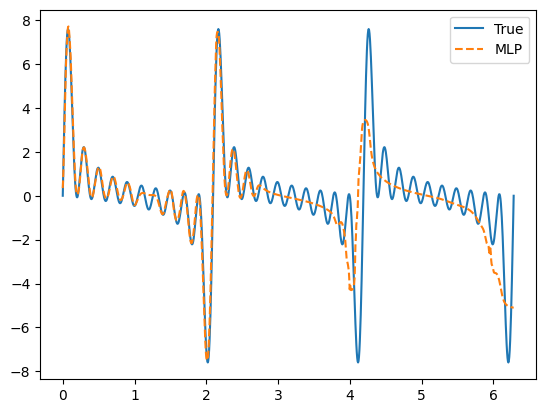

Epoch 50000, Loss 1.461223


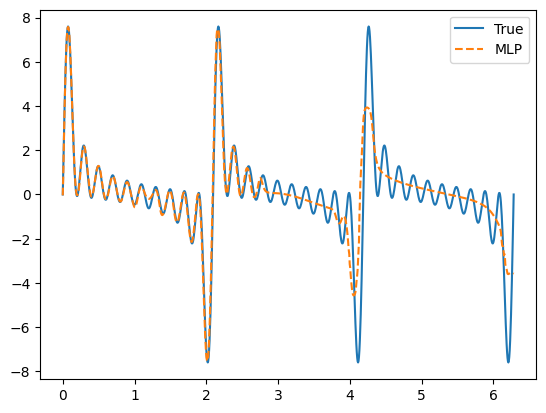

Epoch 60000, Loss 0.989302


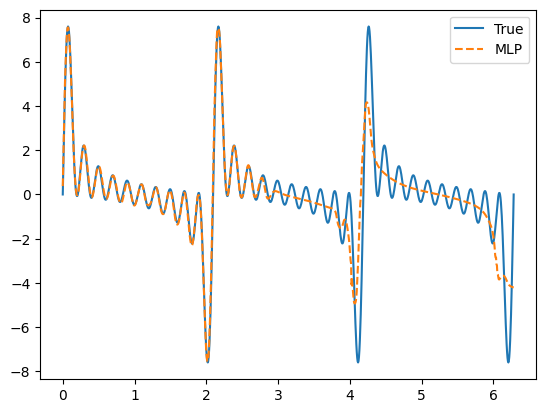

Epoch 70000, Loss 1.029621


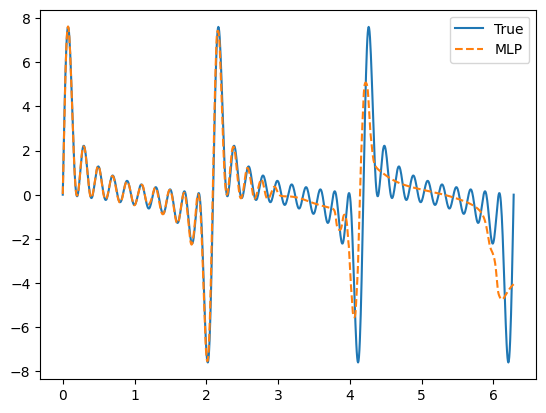

Epoch 80000, Loss 1.039378


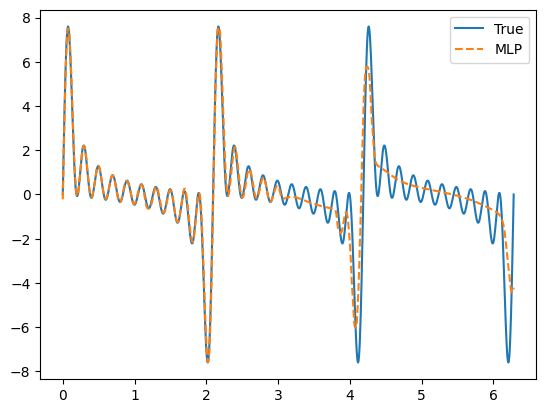

Epoch 90000, Loss 0.746931


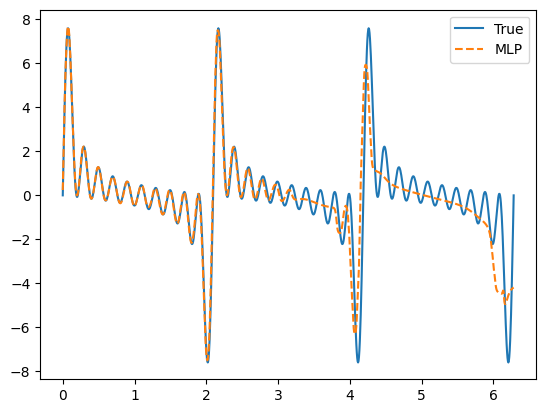

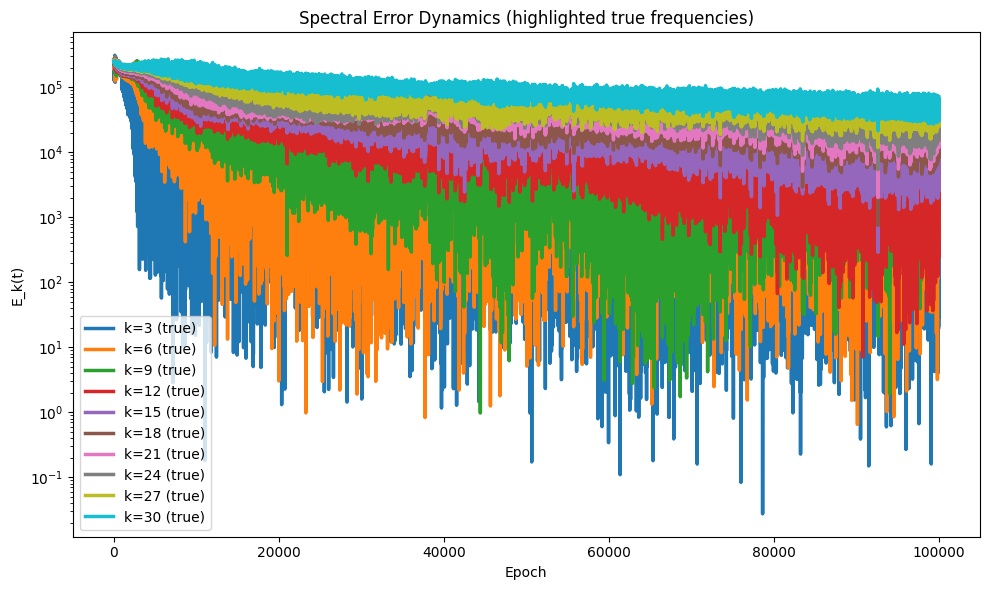

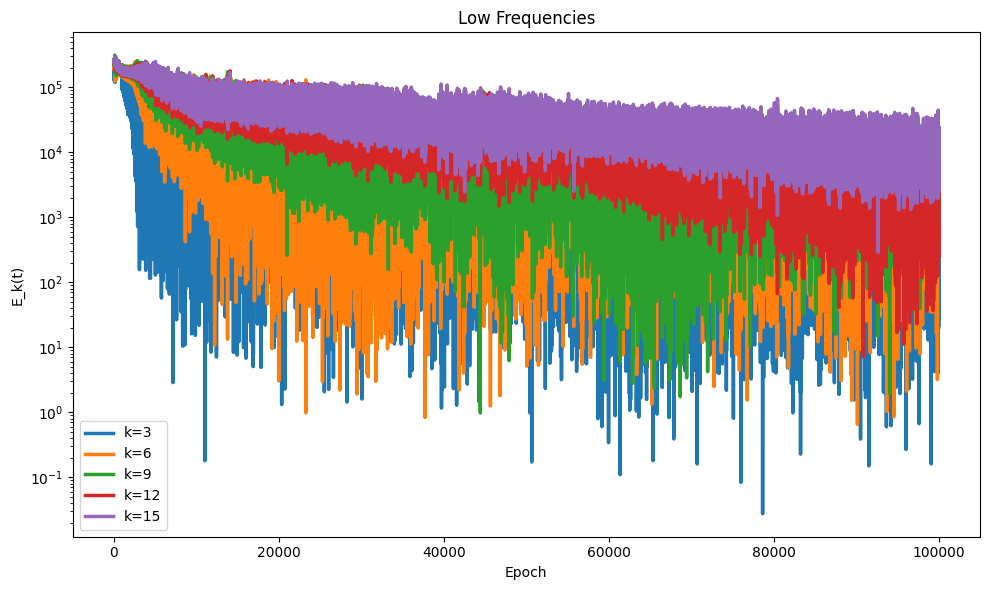

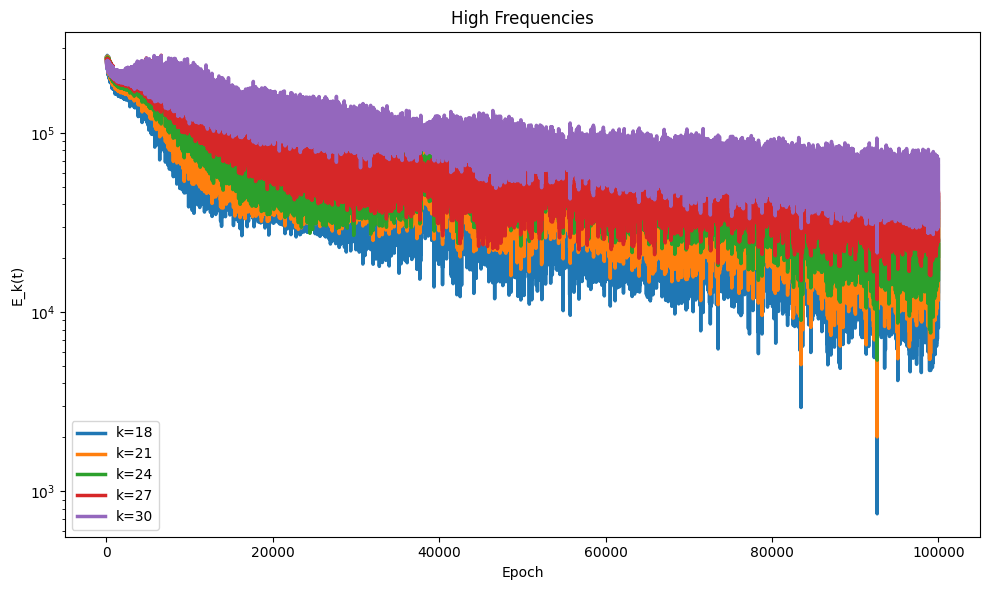

In [16]:
x, y = generate_1d_function(
    freqs=[3, 6, 9, 12, 15, 18, 21, 24, 27, 30],
)

model, spectral_errors, true_fft = train_with_spectral_tracking(
    x, y, epochs=100000, lr = 5e-2, activation='tanh'
)

plot_fit(x, y, model)
plot_spectral_dynamics(spectral_errors, true_freqs=[3, 6, 9, 12, 15, 18, 21, 24, 27, 30])